<a href="https://colab.research.google.com/github/marialuisagama/modelo-usina-solar/blob/main/modelo_usina_solar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Viabilidade de uma Usina Solar
Projeção de caixa, valuation e teste de sensibilidade para projeto de Usina Solar com capex de R$35,000,000.00 e duração de 25 anos, premissas ilustrativas que não vale a pena como investimento.

In [1]:
!pip install numpy-financial
import pandas as pd
import numpy as np
import numpy_financial as npf
import matplotlib.pyplot as plt
pd.options.display.float_format = "{:,.0f}".format

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.5/118.5 kB 1.8 MB/s eta 0:00:00


## Premissas
Meramente ilustrativas, baseadas em médias e estimativas de mercado.

In [2]:
capacidade_mw = 10 #MW
fator_capacidade = 0.25
degradacao = 0.005 #ao ano
tarifa_inicial = 200 # /MWh
ipca = 0.04
om_inicial = 600000 # /ano
capex = 35_000_000.0
anos_operacao = 25
juro_real_livre_risco = 0.07 # IPCA+ 2050
premio_risco = 0.03

## Projeção de fluxo de caixa
Fluxo de caixa por ano, geração diminui com a degradação das placas, tarifa e custo sobem com a inflação (IPCA).

In [3]:
df = pd.DataFrame({"ano": range(0, anos_operacao + 1)})
geracao_ano1 = capacidade_mw * 8760 * fator_capacidade
df["geracao_mwh"]=np.where(df["ano"] == 0,0, (geracao_ano1*((1-degradacao)**(df["ano"]-1))))
df["tarifa"]= np.where(df["ano"] == 0, 0, tarifa_inicial*(1+ipca)**(df["ano"]-1))
df["receita"]= df["geracao_mwh"]*df["tarifa"]
df["custo_om"]= np.where(df["ano"] == 0, 0, om_inicial*(1+ipca)**(df["ano"]-1))
df["capex"]= np.where(df["ano"] == 0, capex,0)
df["fluxo"]= df["receita"] - df["custo_om"] - df["capex"]

df


,ano,geracao_mwh,tarifa,receita,custo_om,capex,fluxo
0,0,0,0,0,0,"35,000,000","-35,000,000"
1,1,"21,900",200,"4,380,000","600,000",0,"3,780,000"
2,2,"21,790",208,"4,532,424","624,000",0,"3,908,424"
3,3,"21,682",216,"4,690,152","648,960",0,"4,041,192"
4,4,"21,573",225,"4,853,370","674,918",0,"4,178,451"
5,5,"21,465",234,"5,022,267","701,915",0,"4,320,352"
6,6,"21,358",243,"5,197,042","729,992",0,"4,467,050"
7,7,"21,251",253,"5,377,899","759,191",0,"4,618,707"
8,8,"21,145",263,"5,565,050","789,559",0,"4,775,491"
9,9,"21,039",274,"5,758,713","821,141",0,"4,937,572"


## Taxa de desconto
NTN-B + prêmio de risco. NTN-B (IPCA+ 2050) é o custo de oportunidade de travar dinheiro por ~25 anos sem risco nenhum. O prêmio de risco compensa o risco de projeto da usina. Assim como O&M e a tarifa são nominais (incluem a inflação), a taxa de desconto tem que ser consistente e nominal.

In [4]:
taxa_real = juro_real_livre_risco + premio_risco
taxa_nominal = (1+taxa_real)*(1+ipca)-1
print(f"A taxa nominal é: {taxa_nominal: .2%}.")

A taxa nominal é:  14.40%.


## Valuation
Cálculo da TIR (Taxa interna de retorno) igual a 13.03%, demonstrando que o projeto não é lucrativo e não deveria ser aprovado. Porém, com a distancia de 1,37 ponto percentual, ele está muito próximo da aprovação, VPL de R$-3,39 milhões.

In [5]:
df["fator_desconto"] = (1+taxa_nominal) **df["ano"]
df["valor_presente"] = df["fluxo"]/df["fator_desconto"]
df["vpl_acumulado"] = df["valor_presente"].cumsum()
print(npf.npv(taxa_nominal, df["fluxo"]))
vpl = df["valor_presente"].sum()
tir = npf.irr(df["fluxo"])
print(f"O VPL desse projeto a taxa de {taxa_nominal: .2%} é de {vpl: .2f}, a TIR é {tir: .2%}.")


-3392827.510106489
O VPL desse projeto a taxa de  14.40% é de -3392827.51, a TIR é  13.03%.


In [6]:
df.style.format("{:,.0f}").format("{:.4f}", subset=["fator_desconto"])


,ano,geracao_mwh,tarifa,receita,custo_om,capex,fluxo,fator_desconto,valor_presente,vpl_acumulado
0,0,0,0,0,0,"35,000,000","-35,000,000",1.0000,"-35,000,000","-35,000,000"
1,1,"21,900",200,"4,380,000","600,000",0,"3,780,000",1.1440,"3,304,196","-31,695,804"
2,2,"21,790",208,"4,532,424","624,000",0,"3,908,424",1.3087,"2,986,411","-28,709,393"
3,3,"21,682",216,"4,690,152","648,960",0,"4,041,192",1.4972,"2,699,178","-26,010,215"
4,4,"21,573",225,"4,853,370","674,918",0,"4,178,451",1.7128,"2,439,559","-23,570,657"
5,5,"21,465",234,"5,022,267","701,915",0,"4,320,352",1.9594,"2,204,900","-21,365,756"
6,6,"21,358",243,"5,197,042","729,992",0,"4,467,050",2.2416,"1,992,804","-19,372,952"
7,7,"21,251",253,"5,377,899","759,191",0,"4,618,707",2.5644,"1,801,102","-17,571,850"
8,8,"21,145",263,"5,565,050","789,559",0,"4,775,491",2.9336,"1,627,833","-15,944,017"
9,9,"21,039",274,"5,758,713","821,141",0,"4,937,572",3.3561,"1,471,225","-14,472,792"


## Análise de Sensibilidade
Demonstração da elasticidade de cada parâmetro no valuation, portanto, a capacidade de cada um de aumentar ou diminuir a lucratividade do projeto.

In [7]:
def calcular_vpl(tarifa_inicial=tarifa_inicial,
                 fator_capacidade=fator_capacidade,
                 capex=capex,
                 om_inicial=om_inicial,
                 taxa_nominal=taxa_nominal):
  df = pd.DataFrame({"ano": range(0, anos_operacao + 1)})
  geracao_ano1 = capacidade_mw * 8760 * fator_capacidade
  df["geracao_mwh"]=np.where(df["ano"] == 0,0, (geracao_ano1*((1-degradacao)**(df["ano"]-1))))
  df["tarifa"]= np.where(df["ano"] == 0, 0, tarifa_inicial*(1+ipca)**(df["ano"]-1))
  df["receita"]= df["geracao_mwh"]*df["tarifa"]
  df["custo_om"]= np.where(df["ano"] == 0, 0, om_inicial*(1+ipca)**(df["ano"]-1))
  df["capex"]= np.where(df["ano"] == 0, capex,0)
  df["fluxo"]= df["receita"] - df["custo_om"] - df["capex"]
  df["fator_desconto"] = (1+taxa_nominal) **df["ano"]
  df["valor_presente"] = df["fluxo"]/df["fator_desconto"]
  return df["valor_presente"].sum()

print(calcular_vpl())
print(calcular_vpl(capex=capex - 3_392_827.51))
print(calcular_vpl(tarifa_inicial=220))
print(calcular_vpl(fator_capacidade=0.30))

-3392827.5101064844
-0.00010648666648194194
291565.12454994296
3975957.7592063784


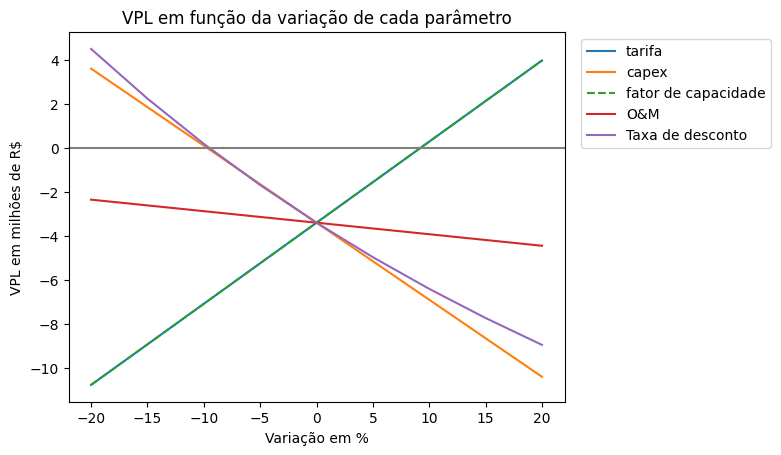

In [8]:
variacoes = np.linspace(-0.2, 0.2, 9)
vpl_tarifa = [calcular_vpl(tarifa_inicial=tarifa_inicial * (1 + v))/1e6 for v in variacoes]
vpl_capex = [calcular_vpl(capex=capex * (1 + v))/1e6 for v in variacoes]
vpl_fator_capacidade = [calcular_vpl(fator_capacidade=fator_capacidade * (1 + v))/1e6 for v in variacoes]
vpl_om = [calcular_vpl(om_inicial=om_inicial * (1 + v))/1e6 for v in variacoes]
vpl_taxa_nominal = [calcular_vpl(taxa_nominal=taxa_nominal * (1 + v))/1e6 for v in variacoes]

plt.plot(variacoes*100 , vpl_tarifa, label="tarifa")
plt.plot(variacoes*100 , vpl_capex, label="capex")
plt.plot(variacoes*100 , vpl_fator_capacidade, label="fator de capacidade", linestyle= "--")
plt.plot(variacoes*100 , vpl_om, label="O&M")
plt.plot(variacoes*100 , vpl_taxa_nominal, label="Taxa de desconto")


plt.axhline(0, color="gray")
plt.title("VPL em função da variação de cada parâmetro")
plt.xlabel("Variação em %")
plt.ylabel("VPL em milhões de R$")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.savefig("sensibilidade.png", dpi=150, bbox_inches="tight")
plt.show()


## Conclusão
Nas premissas atuais, o projeto não deve ser aprovado: a TIR de 13,03% fica 1,37 p.p. abaixo da taxa de desconto exigida de 14,40%, resultando em um VPL -3,39 milhões. Ou seja, o projeto é rentável, mas não o suficiente para remunerar o risco que carrega.
A análise de sensibilidade mostra, porém, que ele está próximo do ponto de viabilidade. Uma redução de cerca de 10% no capex ou na taxa de desconto levaria o VPL a zero, assim como um aumento de cerca de 9% na tarifa ou no fator de capacidade. Já o custo de O&M tem baixa elasticidade e altera pouco o resultado.
Essas premissas, no entanto, não são igualmente controláveis. O capex é a alavanca mais direta, pois depende da negociação dos contratos de construção e de fornecimento. A tarifa depende da forma de comercialização da energia: é pouco negociável em leilões, mas tem mais margem em contratos diretos no mercado livre. O fator de capacidade é definido pela localização e pelo clima, e por isso precisa estar correto já na escolha do terreno. Na taxa de desconto, apenas o prêmio de risco pode ser influenciado, por meio da redução de riscos do projeto ou de uma estrutura de financiamento mais eficiente.
Assim, o projeto se torna viável com um capex de até 31,6 milhões ou com uma tarifa inicial de pelo menos R$ 218/MWh, mantidas as demais premissas.  